In [494]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import random

In [397]:
# Display settings
pd.set_option("display.max_columns", None)

# Load dataset
filePath = "C:/Users/uzair/Downloads/archive (6)/ncr_ride_bookings.csv"
df = pd.read_csv(filePath)

# Basic info
df.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [398]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


DATA CLEANINIG

In [399]:
renameColumns = {
    "Date": "date",
    "Time": "time",
    "Booking ID": "bookingId",
    "Booking Status": "bookingStatus",
    "Customer ID": "customerId",
    "Vehicle Type": "vehicleType",
    "Pickup Location": "pickupLocation",
    "Drop Location": "dropLocation",
    "Avg VTAT": "avgVtat",
    "Avg CTAT": "avgCtat",
    "Cancelled Rides by Customer": "cancelledRidesByCustomer",
    "Reason for cancelling by Customer": "reasonForCancellingByCustomer",
    "Cancelled Rides by Driver": "cancelledRidesByDriver",
    "Driver Cancellation Reason": "driverCancellationReason",
    "Incomplete Rides": "incompleteRides",
    "Incomplete Rides Reason": "incompleteRidesReason",
    "Booking Value": "bookingValue",
    "Ride Distance": "rideDistance",
    "Driver Ratings": "driverRatings",
    "Customer Rating": "customerRating",
    "Payment Method": "paymentMethod"
}
df.rename(columns = renameColumns,inplace= True)

In [400]:
idCols = ['bookingId', 'customerId']
for col in idCols:
    df[col] = df[col].astype(str).str.replace('"', '', regex=False)

In [402]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df['DateTime'] = pd.to_datetime(
    df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time'],
    errors='coerce'
)

In [404]:
df.head()

,date,time,bookingId,bookingStatus,customerId,vehicleType,pickupLocation,dropLocation,avgVtat,avgCtat,cancelledRidesByCustomer,reasonForCancellingByCustomer,cancelledRidesByDriver,driverCancellationReason,incompleteRides,incompleteRidesReason,bookingValue,rideDistance,driverRatings,customerRating,paymentMethod,DateTime
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00


In [405]:
df['day'] = df['DateTime'].dt.day_name()
df['month'] = df['DateTime'].dt.month_name()
df['year'] = df['DateTime'].dt.year
df['hour'] = df['DateTime'].dt.hour

In [411]:
df['incompleteRides'] = df['incompleteRides'].fillna(0).astype(int)
numericColumns = df.select_dtypes(include=np.number).columns
stringColumns = df.select_dtypes(include=['object']).columns

for col in numericColumns:
    df[col] = df[col].fillna(0)

In [417]:
print("Is there any Duplicated:" ,df.duplicated().sum())

Is there any Duplicated: 0


In [419]:
df['paymentMethod'] = df['paymentMethod'].fillna('Not Provided')
df['paymentMethod'].unique()

array(['Not Provided', 'UPI', 'Debit Card', 'Cash', 'Uber Wallet',
       'Credit Card'], dtype=object)

In [523]:
totalRides = df['bookingId'].count()
bookingStatus = df['bookingStatus'].unique()

print("Total Revenue: ",df['bookingValue'].sum())
print('Total Rides', totalRides)

for c in bookingStatus:
    print(f"{c} Revenue: {df.loc[df['bookingStatus']== c , 'bookingValue'].sum()}")
    print(f"Total Ride of {c} : {df.loc[df['bookingStatus']== c , 'bookingId'].count()}")
    

Total Revenue:  51846183.0
Total Rides 150000
No Driver Found Revenue: 0.0
Total Ride of No Driver Found : 10500
Incomplete Revenue: 4585609.0
Total Ride of Incomplete : 9000
Completed Revenue: 47260574.0
Total Ride of Completed : 93000
Cancelled by Driver Revenue: 0.0
Total Ride of Cancelled by Driver : 27000
Cancelled by Customer Revenue: 0.0
Total Ride of Cancelled by Customer : 10500


bookingStatus
Cancelled by Customer           0.0
Cancelled by Driver             0.0
Completed                47260574.0
Incomplete                4585609.0
No Driver Found                 0.0
Name: bookingValue, dtype: float64


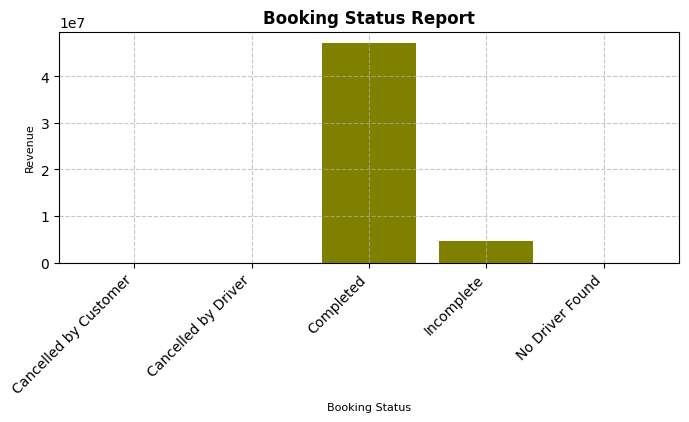

In [498]:
bookingStatusReport = df.groupby('bookingStatus')['bookingValue'].agg('sum')
print(bookingStatusReport)
def barPlot(plotMe,titleText,xlabel,ylabel):
    colors=['olive','darkorchid','salmon','teal','yellowgreen','goldenrod','indigo']
    x = random.randint(0, len(colors))
    plt.figure(figsize=(8,3))
    plt.bar(plotMe.index, plotMe.values, color=colors[x])
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.title(titleText, fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

barPlot(bookingStatusReport,'Booking Status Report', 'Booking Status','Revenue')


driverCancellationReason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64


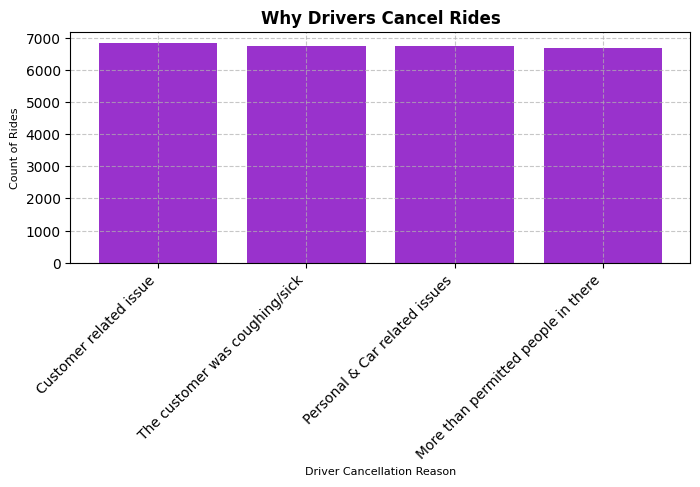

In [499]:
whyDriverCancelRide = df[df['bookingStatus'] == 'Cancelled by Driver']['driverCancellationReason'].value_counts()
print(whyDriverCancelRide)
barPlot(whyDriverCancelRide,'Why Drivers Cancel Rides','Driver Cancellation Reason','Count of Rides')

reasonForCancellingByCustomer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64


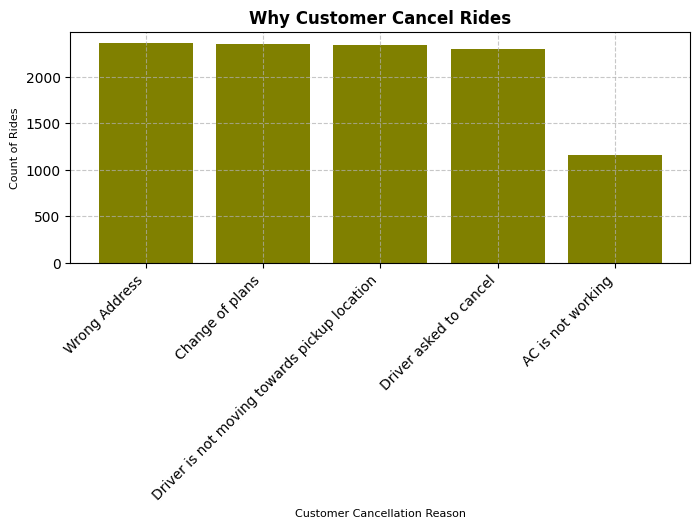

reasonForCancellingByCustomer
Wrong Address                                   22.50
Change of plans                                 22.41
Driver is not moving towards pickup location    22.24
Driver asked to cancel                          21.86
AC is not working                               11.00
Name: proportion, dtype: float64


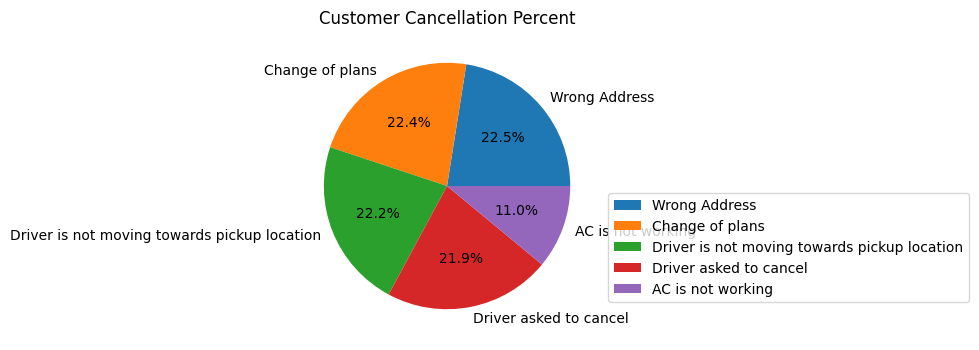

In [532]:
whyCustomerCancelRide = df[df['bookingStatus'] == 'Cancelled by Customer']['reasonForCancellingByCustomer'].value_counts()
print(whyCustomerCancelRide)
barPlot(whyCustomerCancelRide, 'Why Customer Cancel Rides','Customer Cancellation Reason','Count of Rides')

CustomerCancelRate =df[df['bookingStatus'] == 'Cancelled by Customer']['reasonForCancellingByCustomer'].value_counts(normalize=True).mul(100).round(2) 
print(CustomerCancelRate)
def piePlot(plotMe, titleText):
    plt.figure(figsize=(5,4))
    plt.pie(plotMe, labels=plotMe.index, autopct='%1.1f%%')
    plt.legend(plotMe.index, bbox_to_anchor=(1, 0.5))
    plt.title(titleText)
    plt.show()
piePlot(CustomerCancelRate,'Customer Cancellation Percent')

In [320]:
whyCustomerCancelRidePercent = dict()
for idx, val in whyCustomerCancelRide.items():
    whyCustomerCancelRidePercent[idx] = ((val/ whyCustomerCancelRide.sum())*100).round(2)
    print(f"{idx}: {(val/ whyCustomerCancelRide.sum())*100:.2f}%")

# dictionary to series
print('x--------------------------x')
whyCustomerCancelRidePercent = pd.Series(whyCustomerCancelRidePercent)

print(whyCustomerCancelRidePercent)


Wrong Address: 22.50%
Change of plans: 22.41%
Driver is not moving towards pickup location: 22.24%
Driver asked to cancel: 21.86%
AC is not working: 11.00%
x--------------------------x
Wrong Address                                   22.50
Change of plans                                 22.41
Driver is not moving towards pickup location    22.24
Driver asked to cancel                          21.86
AC is not working                               11.00
dtype: float64


In [321]:
cancelledByCustomerDropLocation = df.loc[df['bookingStatus']=='Cancelled by Customer', 'dropLocation'].value_counts()

In [322]:
cancelledByCustomerDriverAskDropLocation = df.loc[(df['bookingStatus'] == 'Cancelled by Customer') & (df['reasonForCancellingByCustomer'] == 'Driver asked to cancel') \
     , 'dropLocation'
     ].value_counts()

In [509]:
df.groupby(['bookingStatus','paymentMethod'])['bookingValue'].agg('sum').sort_values(ascending=False)

bookingStatus          paymentMethod
Completed              UPI              21274591.0
                       Cash             11756071.0
                       Uber Wallet       5669070.0
                       Credit Card       4753767.0
                       Debit Card        3807075.0
Incomplete             UPI               2070510.0
                       Cash              1139578.0
                       Uber Wallet        531828.0
                       Credit Card        470258.0
                       Debit Card         373435.0
Cancelled by Customer  Not Provided            0.0
Cancelled by Driver    Not Provided            0.0
No Driver Found        Not Provided            0.0
Name: bookingValue, dtype: float64

vehicleType
Auto             11727615.0
Bike              7144913.0
Go Mini           9411418.0
Go Sedan          8538560.0
Premier Sedan     5733655.0
Uber XL           1406256.0
eBike             3298157.0
Name: bookingValue, dtype: float64


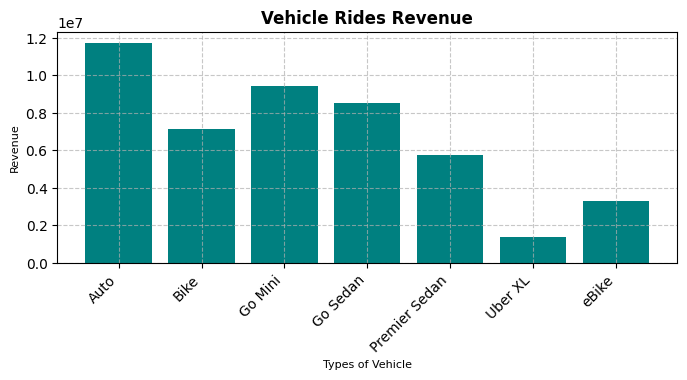

In [501]:
RideVehicleRevenue = completedDf.groupby('vehicleType')['bookingValue'].agg('sum')
print(RideVehicleRevenue)
barPlot(RideVehicleRevenue,'Vehicle Rides Revenue','Types of Vehicle','Revenue')

In [535]:
daysBooking = df.groupby('day')['bookingId'].agg('count').sort_values(ascending=False)
monthBooking = df.groupby('month')['bookingId'].agg('count').sort_values(ascending=False)
hourBooking = df.groupby('hour')['bookingId'].agg('count').sort_values(ascending=False)

daysRevenue = df.groupby('day')['bookingValue'].agg('sum').sort_values(ascending=False)
monthRevenue = df.groupby('month')['bookingValue'].agg('sum').sort_values(ascending=False)
hourRevenue = df.groupby('hour')['bookingValue'].agg('sum').sort_values(ascending=False)

print(daysBooking)
print(monthBooking)
print(hourBooking)

print('x--------------------x')
print(daysRevenue)
print(monthRevenue)
print(hourRevenue)

def linePlot(plotMe,titleText,xlabel,ylabel):
    colors=['olive','darkorchid','salmon','teal','yellowgreen','goldenrod','indigo']
    x = random.randint(0, len(colors))
    plt.figure(figsize=(8,3))
    plt.plot(plotMe.index, plotMe.values, marker='o', linestyle='-', color=colors[x])
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    plt.title(titleText, fontsize=12, fontweight='bold')
    plt.xticks(rotation=35)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()    
  

day
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: bookingId, dtype: int64
month
July         12897
January      12861
May          12778
March        12719
October      12651
August       12636
June         12440
November     12394
December     12250
September    12248
April        12199
February     11927
Name: bookingId, dtype: int64
hour
18    12397
19    11047
17    11044
16     9633
20     9630
10     9577
11     8390
9      8234
15     8202
21     8103
14     7031
12     7006
8      6861
13     5470
7      5450
22     5441
6      4160
5      2786
23     2762
3      1383
0      1373
1      1360
2      1339
4      1321
Name: bookingId, dtype: int64
x--------------------x
day
Sunday       9632687.0
Saturday     9571155.0
Friday       6674597.0
Wednesday    6578787.0
Thursday     6557680.0
Tuesday      6416890.0
Monday       6414387.0
Name: bookingValue, dtype: float64
month
March        4568

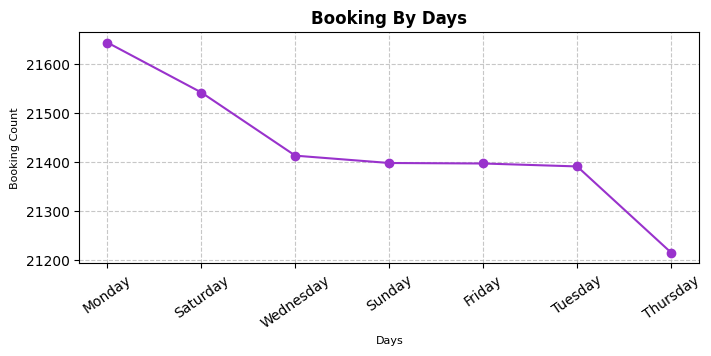

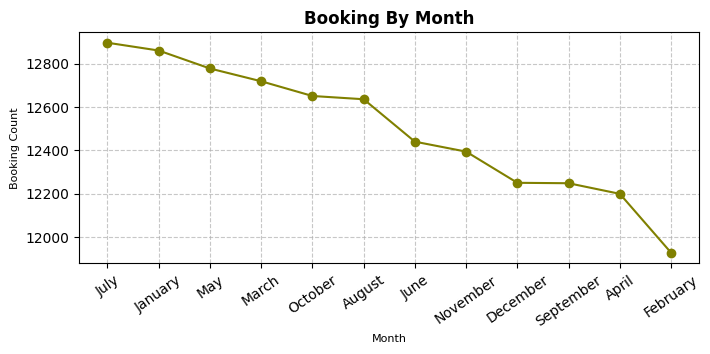

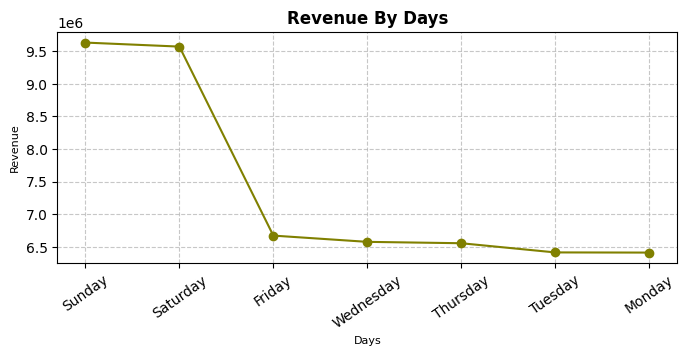

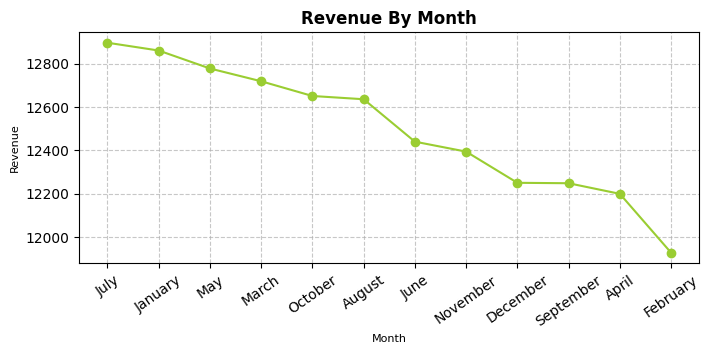

In [537]:
linePlot(daysBooking,'Booking By Days','Days','Booking Count')
linePlot(monthBooking,'Booking By Month','Month','Booking Count')
linePlot(daysRevenue,'Revenue By Days','Days','Revenue')
linePlot(monthBooking,'Revenue By Month','Month','Revenue')

pickupLocation
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Madipur            919
AIIMS              918
Name: bookingId, dtype: int64
dropLocation
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Name: bookingId, dtype: int64
x-------------------------x
pickupLocation
Barakhamba Road    341154.0
Khandsa            338502.0
Subhash Chowk      329386.0
Pataudi Chowk      328572.0
Badarpur           327193.0
Tughlakabad        326283.0
AIIMS              325733.0
Name: bookingValue, dtype: float64
dropLocation
Narsinghpur        354521.0
Sarojini Nagar     335891.0
Mayur Vihar        330384.0
Sarai Kale Khan    327465.0
Lajpat Nagar       327451.0
Samaypur Badli     322676.0
Chirag Delhi       321466.0
Name: bookingValue, dtype: float64


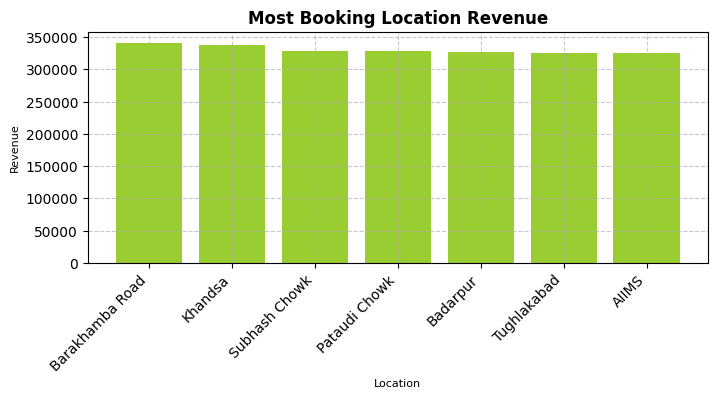

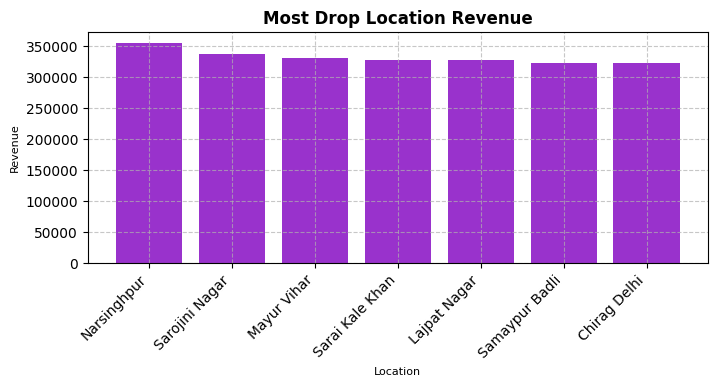

In [511]:
mostBookingLocation = df.groupby('pickupLocation')['bookingId'].agg('count').sort_values(ascending=False).head(7)
mostdropLocation = df.groupby('dropLocation')['bookingId'].agg('count').sort_values(ascending=False).head(7)
print(mostBookingLocation)
print(mostdropLocation)

print('x-------------------------x')
mostBookingLocationRevenue = df.groupby('pickupLocation')['bookingValue'].agg('sum').sort_values(ascending=False).head(7)
mostdropLocationRevenue = df.groupby('dropLocation')['bookingValue'].agg('sum').sort_values(ascending=False).head(7)
print(mostBookingLocationRevenue)
print(mostdropLocationRevenue)

barPlot(mostBookingLocationRevenue,'Most Booking Location Revenue','Location','Revenue')
barPlot(mostdropLocationRevenue,'Most Drop Location Revenue','Location','Revenue')

bookingStatus
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


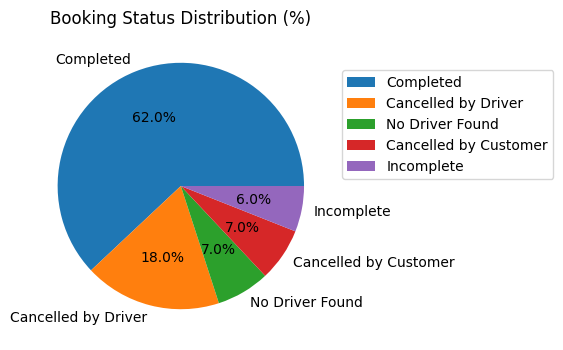

In [533]:
cancelRate = df['bookingStatus'].value_counts(normalize=True) * 100
print(cancelRate)
piePlot(cancelRate,"Booking Status Distribution (%)")


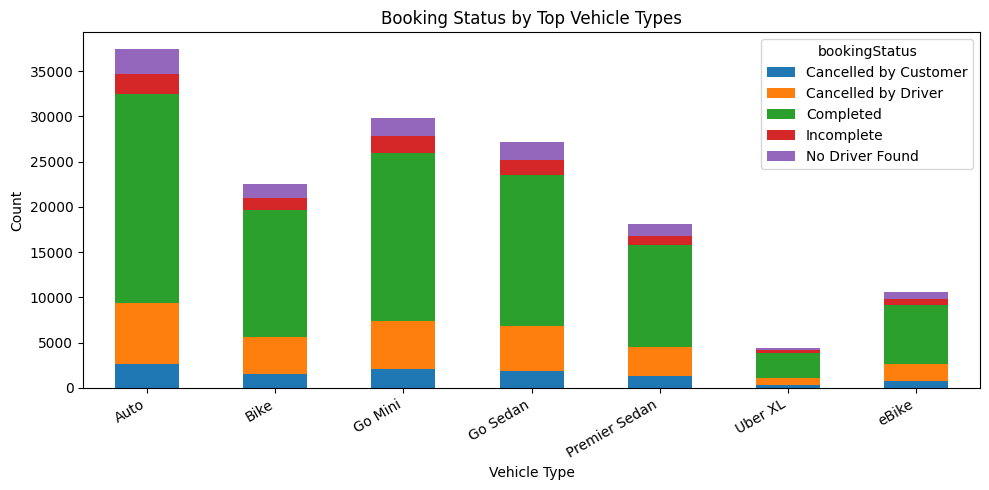

In [541]:
topVehicles = df["vehicleType"].value_counts().head(8).index
tmp = df[df["vehicleType"].isin(topVehicles)]

ct = pd.crosstab(tmp["vehicleType"], tmp["bookingStatus"])
ct.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Booking Status by Top Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()